In [ ]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sc_toolbox as sct

[rank: 0] Global seed set to 0


In [ ]:
mpl.rcParams["figure.figsize"] = (5, 5)

In [ ]:
plt.rcParams['pdf.fonttype'] = 42

In [ ]:
adata = sc.read('../data/cellcharter_dmg_FINAL.h5ad')
adata

AnnData object with n_obs × n_vars = 26552 × 990
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA_MembraneStain_B2M', 'Max.rRNA_MembraneStain_B2M', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'sample', 'sample2', 'orig.ident', 'nCount_Nanostring', 'nFeature_Nanostring', 'Mean.rRNA_CD298_B2M', 'Max.rRNA_CD298_B2M', 'Slide_name', 'Run_name', 'ISH.concentration', 'Beta', 'tissue', 'Run_Slide_name', 'slide_ID_numeric', 'Run_Tissue_name', 'log10totalcounts', 'IFcolor', 'nb_clus', 'leiden_clus', 'id', 'FOV', 'PMCID', 'Replicate', 'ID_R', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'tangram_prediction', 'leiden', 'cellcharter_6', 'cellcharter_9', 'cellcharter_12'
    var: 'n_counts'
    uns: 'PMCID_colors', '_cellcharter', '_scvi_manager_uuid', '_scvi_uuid', 'cluster_cellcharter_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'spatial

In [ ]:
signatures = pd.read_excel('../data/tumor_cell_state_signatures_gavish.xlsx')
signatures.columns = [c.replace('/', '').replace('  ', '_').replace(' - ', '-').replace(' ', '_') for c in signatures.columns]
signatures_dict = signatures.to_dict(orient='list')

In [ ]:
signatures_dict['Cell_Proliferation'] = [x for x in pd.concat((
        signatures['MP1_Cell_Cycle-G2M'],
        signatures['MP2_Cell_Cycle-G1S'],
        signatures['MP3_Cell_Cylce_HMG-rich'],
        signatures['MP4_Cell_Cylce_Chromatin_']
    ))
               if x in adata.var_names]

In [ ]:
signatures_dict['hypoxia_MP6'] = ['VEGFA', 'HILPDA', 'SLC6A6', 'FAM162A', 'NDRG1', 'PDK1', 'INSIG2', 'SLC2A1', 'GBE1', 'AKAP12', 'ERO1A', 'HK2', 'PGK1', 'PLOD2', 'PFKFB4', 'BNIP3L', 'EGLN3', 'BNIP3', 'PFKP', 'PRELID2', 'IGFBP5', 'AK4', 'SORCS3', 'ADM', 'PCBP3', 'SLC2A3', 'CDON', 'DNAH11', 'EPAS1', 'KDM3A', 'ENO1', 'ITPR1', 'TMEM45A', 'DDIT4', 'EGLN1', 'GAPDH', 'P4HA1', 'PPFIA4', 'PRKCB', 'ADCY8', 'C4ORF47', 'CA12', 'CLEC2B', 'ENO2', 'FAM210A', 'IGFBP2', 'NGLY1', 'CDK19', 'CA9', 'ZNF395']

signatures_dict['stress_MP10'] = ['HSPH1', 'HSPE1', 'USPL1', 'CHORDC1', 'HSPD1', 'DNAJB1', 'HSP90AA1', 'HSP90AB1', 'HSPA1A', 'HSPA1B', 'HSPA6', 'CACYBP', 'DNAJB6', 'HSPA4', 'HSPB1', 'ACSL3', 'SERPINH1', 'AHSA1', 'HSPA8', 'TCP1', 'ZFAND2A', 'BAG3', 'CRYAB', 'DNAJB4', 'HES1', 'HSPA4L', 'HSPA9', 'RRAD', 'STIP1', 'UBB', 'UBC', 'ATP2C1', 'DNAJA1', 'DNAJA4', 'ID2', 'MOB4', 'NFKBIA', 'OSBPL3', 'PTGES3', 'SLC38A2', 'PLCG2', 'PLOD2', 'GEM', 'TENT4B', 'C11ORF96', 'TAF7', 'OAZ1', 'ADM', 'CD83', 'TNFAIP3']

In [ ]:
def score_cells(adata, signature_name, genes):
    adata.obs[f'score_{signature_name}'] = np.nan
    for FOV in adata.obs['FOV'].cat.categories:
        adata_FOV = adata[adata.obs['FOV'] == FOV].copy()
        sc.tl.score_genes(adata_FOV, gene_list=[x for x in genes if x in adata_FOV.var_names], score_name=f'score_{signature_name}')
        adata.obs[f'score_{signature_name}'][adata.obs['FOV'] == FOV] = adata_FOV.obs[f'score_{signature_name}']

In [ ]:
def smooth_signature(adata, signature_name, n_neighbors, group_key=None, groups=None):
    if groups:
        adata_groups = adata[adata.obs[group_key].isin(groups)]
    sq.gr.spatial_neighbors(adata_groups, library_key='sample', n_neighs=n_neighbors, coord_type='generic')
    adata_groups.obsp['spatial_connectivities'].setdiag(1)
    
    adata.obs[f'score_{signature_name}_smoothed'] = np.nan
    for FOV in adata_groups.obs['FOV'].cat.categories:
        adata_groups_FOV = adata_groups[adata_groups.obs['FOV'] == FOV]
        adata_groups_FOV.obs[f'score_{signature_name}_smoothed'] = np.nan*np.ones(adata_groups_FOV.shape[0])
        adj = adata_groups_FOV.obsp['spatial_connectivities']
        score_smoothed = (adj @ adata_groups_FOV.obs[f'score_{signature_name}']) / np.array(np.sum(adj, axis=1)).squeeze()
        score_smoothed[score_smoothed == float('inf')] = 0

        low = np.nanpercentile(score_smoothed, 5)
        score_smoothed[score_smoothed < low] = low

        high = np.nanpercentile(score_smoothed, 95)
        score_smoothed[score_smoothed > high] = high

        adata.obs[f'score_{signature_name}_smoothed'][(adata.obs['FOV'] == FOV) & (adata.obs[group_key].isin(groups))] = score_smoothed
    

In [ ]:
signatures_names  = ['hypoxia_MP6', 'stress_MP10', 'MP13_EMT-II', 'MP6_Hypoxia', 'Cell_Proliferation']

for SIGNATURE_NAME in signatures_names:
    score_cells(adata, SIGNATURE_NAME, signatures_dict[SIGNATURE_NAME])
    smooth_signature(adata, SIGNATURE_NAME, 50, 'tangram_prediction', ['RG_like', 'Tri_IPC_like', 'nIPC_like', 'OPC_like', 'COP_like',
    'AC_like', 'Cilia_like', 'TD_like', 'GW_like'])

/scratch-local/cruiz2.6919718/ipykernel_683750/3814498655.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata.obs[f'score_{signature_name}'][adata.obs['FOV'] == FOV] = adata_FOV.obs[f'score_{signature_name}']
/scratch-local/cruiz2.6919

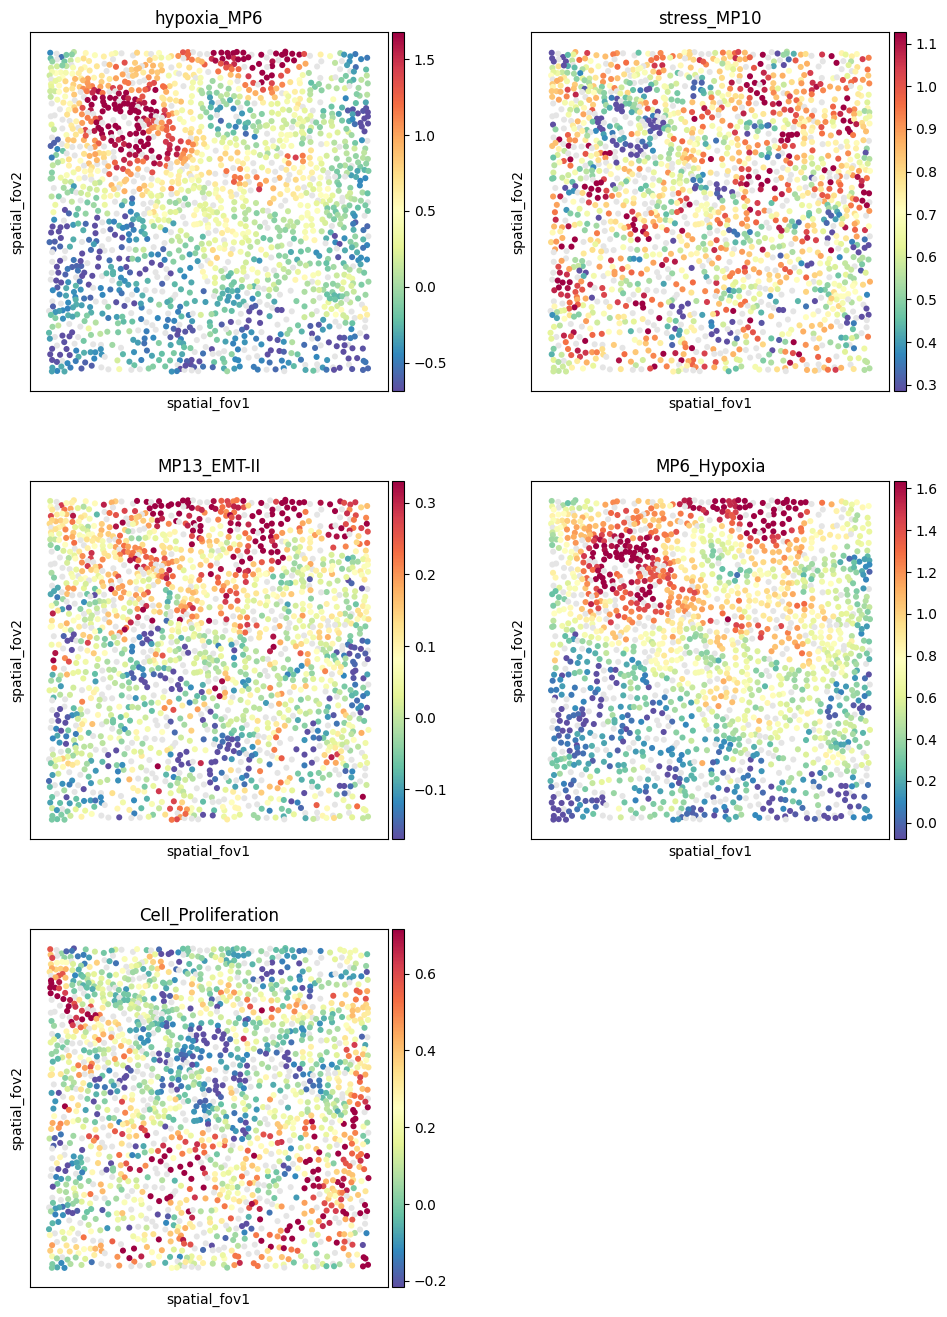

In [ ]:
sq.pl.spatial_scatter(
    adata[adata.obs.FOV == 'Run5779_S3_FOV14'], 
    color=[f'score_{signature}_smoothed' for signature in signatures_names],
    cmap='Spectral_r',
    library_key='sample',  
    size=40, 
    img=None,
    spatial_key='spatial_fov',
    na_color="#E5E5E5",
    #connectivity_key='spatial_connectivities',
    #img_alpha=0.3,
    figsize=(5,5),
    ncols=2,
    title=['hypoxia_MP6', 'stress_MP10', 'MP13_EMT-II', 'MP6_Hypoxia', 'Cell_Proliferation'],
    #library_id=adata.obs['sample'].unique(),
    library_id=['R5779_TMA3-S4'],
     save='figures/signatures_Run5779_S3_FOV14.pdf'
)